# Background
We are developing a data analysis pipeline to characterise the substrate features:
1. radial colour variation
2. angular colour variation
3. centre vs edge intensity ratio

In [ ]:
import os
import sys

sys.path.append('../../..')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes

In [ ]:
filepath = r'/Users/kuning/Documents/GitHub/OpenSERS-utils/substrate_BF_characterisation/test dataset/condition 1_replicate 1_result_sBFc_v1.1.npz'
arr:np.ndarray = np.load(filepath, allow_pickle=True)['arr_0']

/var/folders/fm/28xyzlz53pjg6blxlwwr9y940000gn/T/ipykernel_89455/574969862.py:2: RuntimeWarning: invalid value encountered in cast
  plt.imshow(arr.astype(np.uint8))


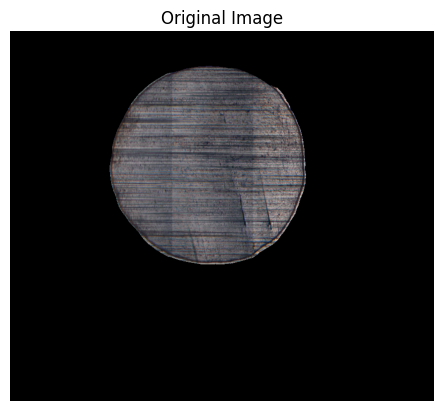

In [17]:
# Show the image stored
plt.imshow(arr.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

# Fitting

In [18]:
import numpy as np
from skimage import morphology

def get_boundary_pixels(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract the outermost boundary pixel coordinates of the substrate mask.
    
    Args:
        arr (np.ndarray): Masked image array (H x W x 3, float) with NaN outside substrate
    
    Returns:
        tuple[np.ndarray, np.ndarray]: (ys, xs) coordinates of boundary pixels
    """
    # Build binary mask from non-NaN pixels
    mask = ~np.isnan(arr[:, :, 0])
    
    # Erode mask by 1 pixel, boundary = mask - eroded
    eroded = morphology.erosion(mask, morphology.disk(1))
    boundary = mask & ~eroded
    
    ys, xs = np.where(boundary)
    return ys, xs

/var/folders/fm/28xyzlz53pjg6blxlwwr9y940000gn/T/ipykernel_89455/424715481.py:3: RuntimeWarning: invalid value encountered in cast
  plt.imshow(arr.astype(np.uint8))


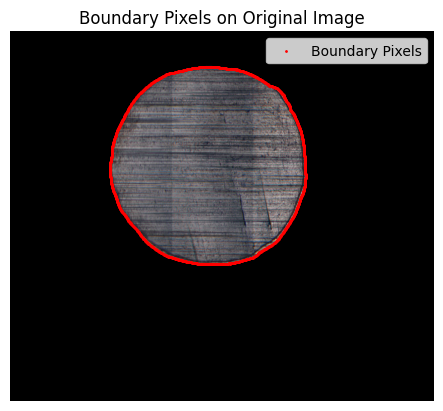

In [19]:
ys, xs = get_boundary_pixels(arr)

plt.imshow(arr.astype(np.uint8))
plt.scatter(xs, ys, s=1, c='red', label='Boundary Pixels')
plt.title('Boundary Pixels on Original Image')
plt.axis('off')
plt.legend()
plt.show()

In [20]:
from substrate_BF_characterisation.masking.fitting import fit_ellipse_ransac, Ellipse_Cartesian, EllipseFitResult

def get_boundary_ellipse(arr: np.ndarray) -> EllipseFitResult:
    """
    Extract boundary pixels from masked image and fit a RANSAC ellipse to them.
    
    Args:
        arr (np.ndarray): Masked image array (H x W x 3, float) with NaN outside substrate
    
    Returns:
        EllipseFitResult: Fitted ellipse parameters and inliers
    """
    # Get boundary pixels
    ys, xs = get_boundary_pixels(arr)
    
    ellipse = Ellipse_Cartesian(x=xs,y=ys)
    
    # Fit ellipse using existing RANSAC function
    ellipse_fit = fit_ellipse_ransac(ellipse)
    
    return ellipse_fit

In [21]:
import json

ellipse_fit_result = get_boundary_ellipse(arr)

print("Fitted Ellipse Parameters:")
print(json.dumps({k: v for k,v in ellipse_fit_result.__dict__.items() if isinstance(v, (int, float, str))}, indent=4))

print(json.dumps({k: f'{type(v)}' for k,v in ellipse_fit_result.__dict__.items() if not isinstance(v, (int, float, str))}, indent=4))

Fitted Ellipse Parameters:
{
    "xc": 398.6762134273247,
    "yc": 269.09144014717083,
    "a": 200.6263303556142,
    "b": 196.29598584039292,
    "theta": 1.4065152484767536,
    "major_d": 401.2526607112284,
    "minor_d": 392.59197168078583,
    "circularity": 0.9998214735745672,
    "inlier_ratio": 0.9512619669277633
}
{
    "inliers": "<class 'numpy.ndarray'>",
    "model": "<class 'skimage.measure.fit.EllipseModel'>"
}


# Characterisations

In [22]:
from substrate_BF_characterisation.masking.basic_image_processing import convert_img_RGB2HSV

In [23]:
# Generate the mask for the arr based on the arr values (if it's NaN or not)
mask = ~np.isnan(arr[:,:,0])
arr_uint8 = np.nan_to_num(arr, nan=0).clip(0, 255).astype(np.uint8)
arr_hsv = convert_img_RGB2HSV(arr_uint8)

In [24]:
import scipy.stats as stats

def calculate_radial_colour_variation(arr, arr_hsv, mask, xc, yc):
    """
    Pearson correlation between each HSV channel and radial distance from centre.
    Tracks radial uniformity — coffee ring effect shows high S correlation with radius.
    Returns H_r, H_p, S_r, S_p, V_r, V_p (r = correlation, p = p-value)
    """
    ys, xs = np.where(mask)
    radii = np.sqrt((xs - xc)**2 + (ys - yc)**2)
    H_r, H_p = stats.pearsonr(radii, arr_hsv[:,:,0][mask])
    S_r, S_p = stats.pearsonr(radii, arr_hsv[:,:,1][mask])
    V_r, V_p = stats.pearsonr(radii, arr_hsv[:,:,2][mask])
    return dict(H_r=H_r, H_p=H_p, S_r=S_r, S_p=S_p, V_r=V_r, V_p=V_p)


def calculate_angular_colour_variation(arr, arr_hsv, mask, xc, yc):
    """
    Pearson correlation between each HSV channel and angular position.
    Angle is decomposed into sin/cos to handle circular wrap-around.
    Returns H_cos_r, H_cos_p, H_sin_r, H_sin_p (and same for S, V)
    """
    ys, xs = np.where(mask)
    angles = np.arctan2(ys - yc, xs - xc)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    results = {}
    for i, ch in enumerate(['H', 'S', 'V']):
        ch_vals = arr_hsv[:,:,i][mask]
        r_cos, p_cos = stats.pearsonr(cos_a, ch_vals)
        r_sin, p_sin = stats.pearsonr(sin_a, ch_vals)
        results.update({f'{ch}_cos_r': r_cos, f'{ch}_cos_p': p_cos,
                        f'{ch}_sin_r': r_sin, f'{ch}_sin_p': p_sin})
    return results


def calculate_centre_edge_ratio(arr, arr_hsv, mask, xc, yc, inner_fraction=0.5):
    """
    Mean HSV in inner vs outer region of substrate.
    Ratio > 1 = centre-heavy deposition, < 1 = edge-heavy (coffee ring).
    Returns H/S/V _inner, _outer, _ratio
    """
    ys, xs = np.where(mask)
    radii = np.sqrt((xs - xc)**2 + (ys - yc)**2)
    r_threshold = radii.max() * inner_fraction
    inner = radii <= r_threshold
    outer = radii >  r_threshold
    results = {}
    for i, ch in enumerate(['H', 'S', 'V']):
        ch_vals = arr_hsv[:,:,i][mask]
        inner_mean = ch_vals[inner].mean()
        outer_mean = ch_vals[outer].mean()
        results.update({f'{ch}_inner': inner_mean, f'{ch}_outer': outer_mean,
                        f'{ch}_ratio': inner_mean / outer_mean if outer_mean != 0 else np.nan})
    return results

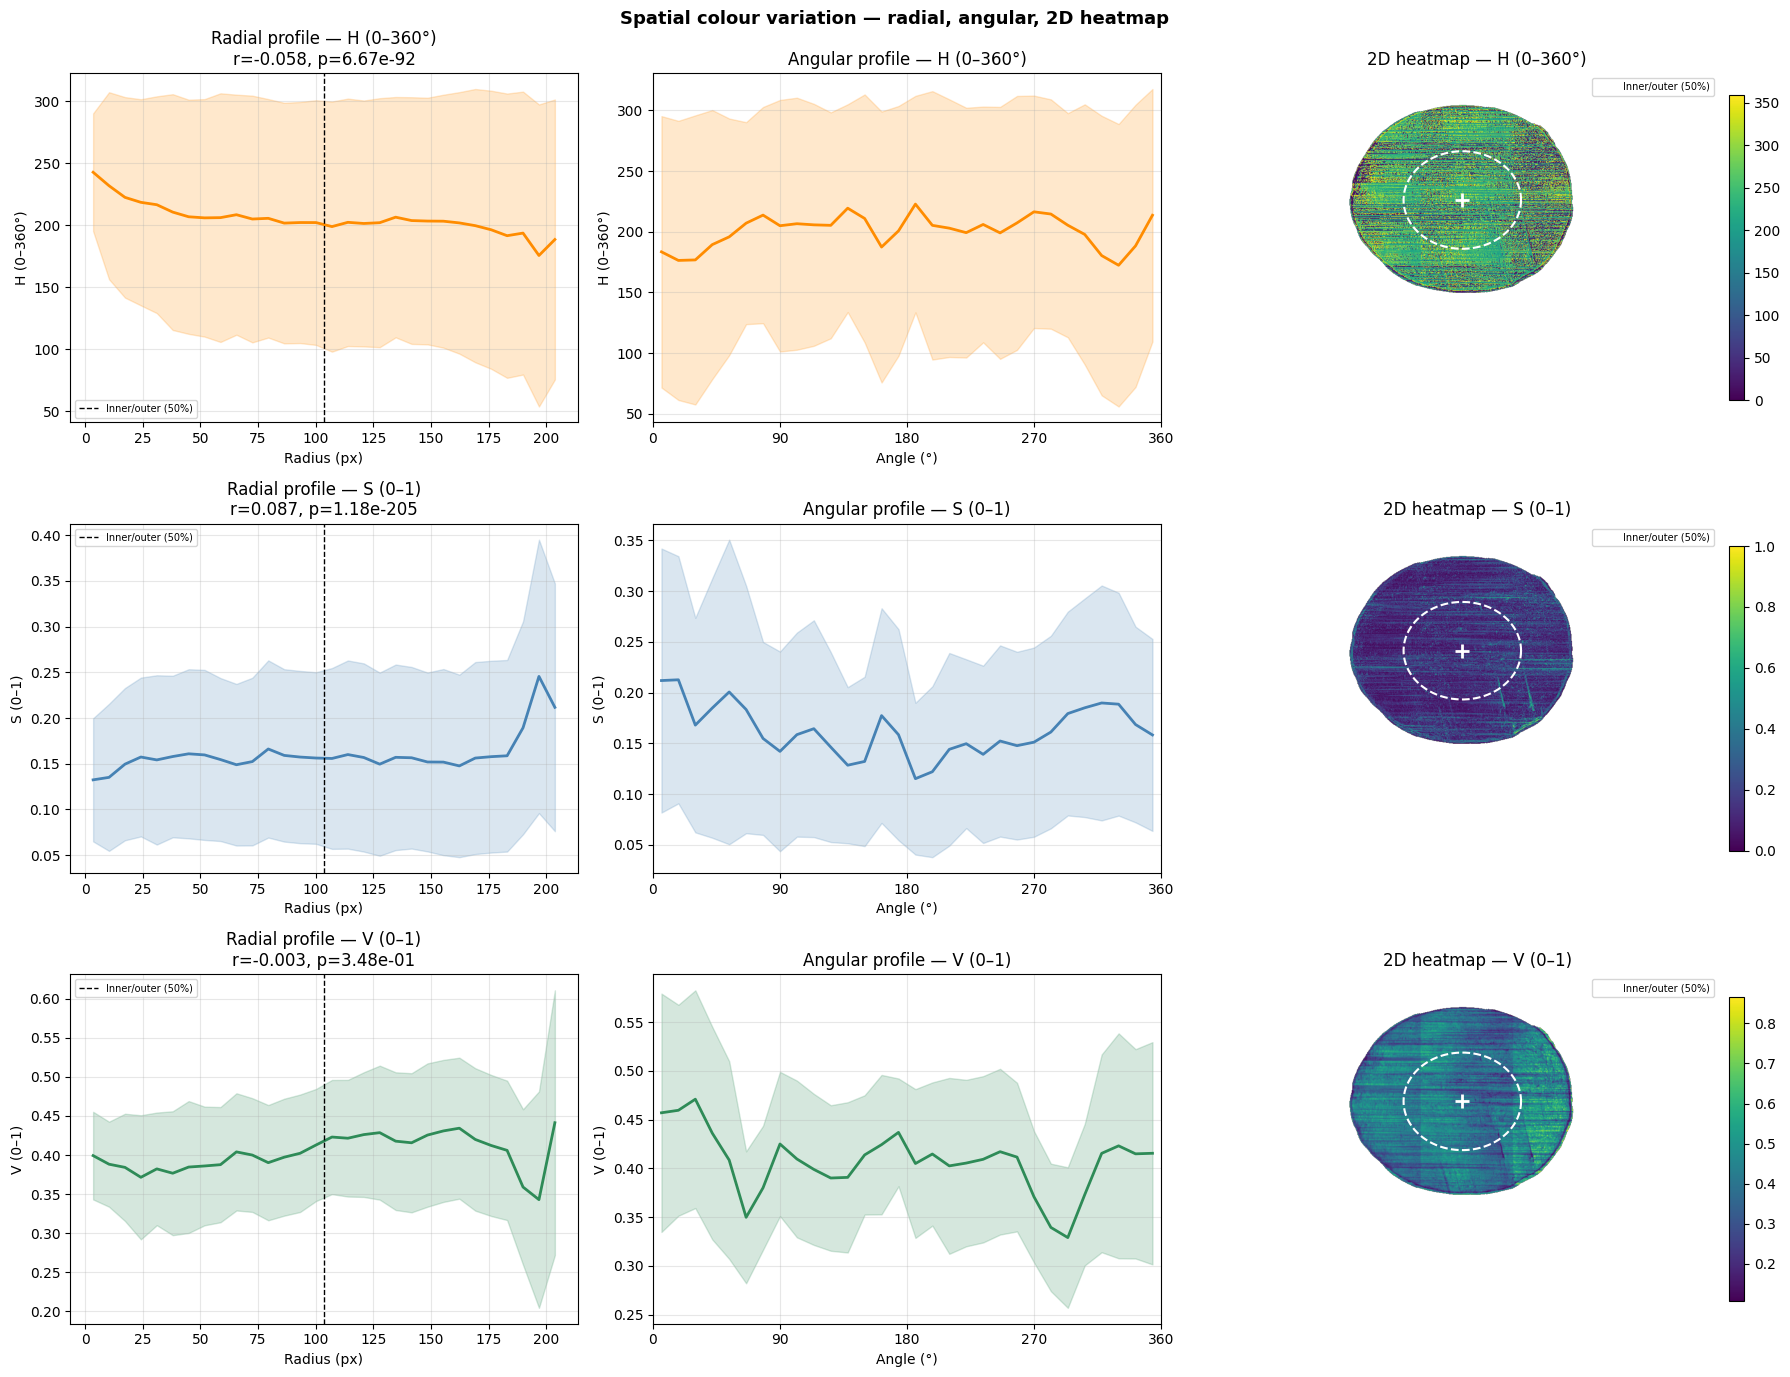

In [ ]:
def plot_spatial_variation(arr_hsv: np.ndarray, mask: np.ndarray, xc: float, yc: float,
                           inner_fraction: float = 0.5, n_bins: int = 30) -> Figure:
    """
    Plot spatial colour variation visualisations for radial, angular, and 2D heatmap.

    Each row corresponds to one HSV channel (H, S, V). Columns are:
        - Col 0: Radial profile — binned mean ± std vs radius, with Pearson r and p-value
        - Col 1: Angular profile — binned mean ± std vs angle (0–360°)
        - Col 2: 2D heatmap — spatial map of each channel with inner/outer boundary circle

    Args:
        arr_hsv (np.ndarray): HSV image array (H x W x 3, float32) with H in degrees (0-360), S and V in range 0-1
        mask (np.ndarray): Boolean mask (H x W), True inside substrate
        xc (float): x-coordinate of substrate centre
        yc (float): y-coordinate of substrate centre
        inner_fraction (float): Fraction of max radius defining inner/outer boundary (default 0.5)
        n_bins (int): Number of bins for radial and angular profiles (default 30)

    Returns:
        Figure: Matplotlib figure containing the 3x3 grid of spatial variation plots
    """
    ys, xs = np.where(mask)
    radii  = np.sqrt((xs - xc)**2 + (ys - yc)**2)
    angles = np.degrees(np.arctan2(ys - yc, xs - xc)) % 360

    H_vals = arr_hsv[:, :, 0][mask]
    S_vals = arr_hsv[:, :, 1][mask]
    V_vals = arr_hsv[:, :, 2][mask]

    ch_names  = ['H (0-360°)', 'S (0-1)', 'V (0-1)']
    ch_vals   = [H_vals, S_vals, V_vals]
    ch_colors = ['darkorange', 'steelblue', 'seagreen']

    r_max       = radii.max()
    r_threshold = r_max * inner_fraction

    fig, axes = plt.subplots(3, 3, figsize=(18, 14))

    for col, (ch_name, ch, color) in enumerate(zip(ch_names, ch_vals, ch_colors)):

        # Col 0: Radial profile
        r_bins    = np.linspace(0, r_max, n_bins + 1)
        r_centres = (r_bins[:-1] + r_bins[1:]) / 2
        r_means, r_stds = [], []
        for i in range(n_bins):
            in_bin = (radii >= r_bins[i]) & (radii < r_bins[i+1])
            r_means.append(ch[in_bin].mean() if in_bin.sum() > 0 else np.nan)
            r_stds.append(ch[in_bin].std()   if in_bin.sum() > 0 else np.nan)
        r_means, r_stds = np.array(r_means), np.array(r_stds)

        r_corr, r_p = stats.pearsonr(radii, ch)
        axes[col, 0].plot(r_centres, r_means, color=color, linewidth=2)
        axes[col, 0].fill_between(r_centres, r_means - r_stds, r_means + r_stds,
                                   alpha=0.2, color=color)
        axes[col, 0].axvline(r_threshold, color='k', linestyle='--',
                              linewidth=1, label=f'Inner/outer ({int(inner_fraction*100)}%)')
        axes[col, 0].set_xlabel('Radius (px)')
        axes[col, 0].set_ylabel(ch_name)
        axes[col, 0].set_title(f'Radial profile — {ch_name}\nr={r_corr:.3f}, p={r_p:.2e}')
        axes[col, 0].legend(fontsize=7)
        axes[col, 0].grid(True, alpha=0.3)

        # Col 1: Angular profile
        a_bins    = np.linspace(0, 360, n_bins + 1)
        a_centres = (a_bins[:-1] + a_bins[1:]) / 2
        a_means, a_stds = [], []
        for i in range(n_bins):
            in_bin = (angles >= a_bins[i]) & (angles < a_bins[i+1])
            a_means.append(ch[in_bin].mean() if in_bin.sum() > 0 else np.nan)
            a_stds.append(ch[in_bin].std()   if in_bin.sum() > 0 else np.nan)
        a_means, a_stds = np.array(a_means), np.array(a_stds)

        axes[col, 1].plot(a_centres, a_means, color=color, linewidth=2)
        axes[col, 1].fill_between(a_centres, a_means - a_stds, a_means + a_stds,
                                   alpha=0.2, color=color)
        axes[col, 1].set_xlabel('Angle (°)')
        axes[col, 1].set_ylabel(ch_name)
        axes[col, 1].set_title(f'Angular profile — {ch_name}')
        axes[col, 1].set_xlim(0, 360)
        axes[col, 1].set_xticks([0, 90, 180, 270, 360])
        axes[col, 1].grid(True, alpha=0.3)

        # Col 2: 2D heatmap
        heatmap = arr_hsv[:, :, col].copy()
        heatmap[~mask] = np.nan
        im = axes[col, 2].imshow(heatmap, cmap='viridis', aspect='auto')
        plt.colorbar(im, ax=axes[col, 2], fraction=0.03, pad=0.02)
        theta_circle = np.linspace(0, 2*np.pi, 360)
        axes[col, 2].plot(xc + r_threshold * np.cos(theta_circle),
                          yc + r_threshold * np.sin(theta_circle),
                          'w--', linewidth=1.5, label=f'Inner/outer ({int(inner_fraction*100)}%)')
        axes[col, 2].plot(xc, yc, 'w+', markersize=10, markeredgewidth=2)
        axes[col, 2].set_title(f'2D heatmap — {ch_name}')
        axes[col, 2].legend(fontsize=7)
        axes[col, 2].axis('off')

    plt.suptitle('Spatial colour variation — radial, angular, 2D heatmap',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_spatial_variation(arr_hsv, mask, xc=ellipse_fit_result.xc, yc=ellipse_fit_result.yc,
                            inner_fraction=0.5, n_bins=30)
plt.show()

In [30]:
from scipy.signal import find_peaks

def extract_radial_features(arr_hsv: np.ndarray, mask: np.ndarray,
                             xc: float, yc: float, n_bins: int = 30) -> dict:
    """
    Extract scalar features from the radial intensity profile of each HSV channel.

    Features per channel:
        - pearson_r, pearson_p : linear correlation with radius
        - peak_radius          : radius at which channel peaks (normalised 0-1)
        - std                  : std of channel values across all radii
        - slope                : slope of linear fit to binned radial profile
        - skewness             : skewness of channel values (positive = tail toward edge)

    Args:
        arr_hsv (np.ndarray): HSV image array (H x W x 3, float32)
        mask (np.ndarray)   : Boolean mask, True inside substrate
        xc, yc (float)      : Substrate centre coordinates
        n_bins (int)        : Number of radial bins

    Returns:
        dict: Scalar features prefixed by channel name e.g. 'S_peak_radius'
    """
    ys, xs = np.where(mask)
    radii  = np.sqrt((xs - xc)**2 + (ys - yc)**2)
    r_max  = radii.max()
    r_bins    = np.linspace(0, r_max, n_bins + 1)
    r_centres = (r_bins[:-1] + r_bins[1:]) / 2

    results = {}
    for i, ch_name in enumerate(['H', 'S', 'V']):
        ch = arr_hsv[:, :, i][mask]

        # Pearson r
        r_corr, r_p = stats.pearsonr(radii, ch)

        # Binned profile
        r_means = []
        for j in range(n_bins):
            in_bin = (radii >= r_bins[j]) & (radii < r_bins[j+1])
            r_means.append(ch[in_bin].mean() if in_bin.sum() > 0 else np.nan)
        r_means = np.array(r_means)

        # Peak radius (normalised 0-1)
        valid = ~np.isnan(r_means)
        peak_radius = r_centres[valid][np.argmax(r_means[valid])] / r_max

        # Slope of linear fit to binned profile
        slope, _, _, _, _ = stats.linregress(r_centres[valid], r_means[valid])

        results.update({
            f'{ch_name}_pearson_r'   : r_corr,
            f'{ch_name}_pearson_p'   : r_p,
            f'{ch_name}_peak_radius' : peak_radius,
            f'{ch_name}_std'         : ch.std(),
            f'{ch_name}_slope'       : slope,
            f'{ch_name}_skewness'    : stats.skew(ch),
        })

    return results


def extract_angular_features(arr_hsv: np.ndarray, mask: np.ndarray,
                              xc: float, yc: float, n_bins: int = 36) -> dict:
    """
    Extract scalar features from the angular intensity profile of each HSV channel.

    Features per channel:
        - angular_std        : std of binned angular profile (uniformity)
        - peak_to_peak       : max - min of binned profile (asymmetry amplitude)
        - n_peaks            : number of local maxima in angular profile
        - dominant_frequency : dominant FFT frequency (cycles/revolution)

    Args:
        arr_hsv (np.ndarray): HSV image array (H x W x 3, float32)
        mask (np.ndarray)   : Boolean mask, True inside substrate
        xc, yc (float)      : Substrate centre coordinates
        n_bins (int)        : Number of angular bins (default 36 = 10° per bin)

    Returns:
        dict: Scalar features prefixed by channel name e.g. 'S_angular_std'
    """
    ys, xs = np.where(mask)
    angles = np.degrees(np.arctan2(ys - yc, xs - xc)) % 360
    a_bins = np.linspace(0, 360, n_bins + 1)

    results = {}
    for i, ch_name in enumerate(['H', 'S', 'V']):
        ch = arr_hsv[:, :, i][mask]

        # Binned profile
        a_means = []
        for j in range(n_bins):
            in_bin = (angles >= a_bins[j]) & (angles < a_bins[j+1])
            a_means.append(ch[in_bin].mean() if in_bin.sum() > 0 else np.nan)
        a_means = np.array(a_means)
        profile = a_means[~np.isnan(a_means)]

        # Dominant FFT frequency (exclude DC at index 0)
        fft_mag = np.abs(np.fft.rfft(profile - profile.mean()))
        freqs   = np.fft.rfftfreq(len(profile), d=1/n_bins)
        dominant_freq = freqs[1:][np.argmax(fft_mag[1:])] if len(fft_mag) > 1 else 0.0

        peaks, _ = find_peaks(profile)
        results.update({
            f'{ch_name}_angular_std'        : profile.std(),
            f'{ch_name}_peak_to_peak'       : profile.max() - profile.min(),
            f'{ch_name}_n_peaks'            : len(peaks),
            f'{ch_name}_dominant_frequency' : dominant_freq,
        })

    return results


def extract_spatial_features(arr_hsv: np.ndarray, mask: np.ndarray,
                              xc: float, yc: float) -> dict:
    """
    Extract 2D spatial scalar features from each HSV channel.

    Features per channel:
        - q1_mean, q2_mean, q3_mean, q4_mean : mean per quadrant
                                                (Q1=top-right, Q2=top-left,
                                                 Q3=bottom-left, Q4=bottom-right)
        - quadrant_std      : std of four quadrant means (overall asymmetry)
        - moment_of_inertia : intensity-weighted mean r² (spread from centre)
        - entropy           : Shannon entropy of intensity histogram

    Args:
        arr_hsv (np.ndarray): HSV image array (H x W x 3, float32)
        mask (np.ndarray)   : Boolean mask, True inside substrate
        xc, yc (float)      : Substrate centre coordinates

    Returns:
        dict: Scalar features prefixed by channel name e.g. 'S_quadrant_std'
    """
    ys, xs = np.where(mask)
    radii  = np.sqrt((xs - xc)**2 + (ys - yc)**2)

    q1 = (xs >= xc) & (ys <  yc)   # top-right
    q2 = (xs <  xc) & (ys <  yc)   # top-left
    q3 = (xs <  xc) & (ys >= yc)   # bottom-left
    q4 = (xs >= xc) & (ys >= yc)   # bottom-right

    results = {}
    for i, ch_name in enumerate(['H', 'S', 'V']):
        ch = arr_hsv[:, :, i][mask]

        q_means = [ch[q].mean() if q.sum() > 0 else np.nan
                   for q in [q1, q2, q3, q4]]

        # Moment of inertia: intensity-weighted mean r²
        ch_shifted = ch - ch.min() + 1e-8
        moi = np.sum(ch_shifted * radii**2) / np.sum(ch_shifted)

        # Shannon entropy
        hist, _ = np.histogram(ch, bins=50, density=True)
        hist     = hist[hist > 0]
        entropy  = -np.sum(hist * np.log(hist))

        results.update({
            f'{ch_name}_q1_mean'          : q_means[0],
            f'{ch_name}_q2_mean'          : q_means[1],
            f'{ch_name}_q3_mean'          : q_means[2],
            f'{ch_name}_q4_mean'          : q_means[3],
            f'{ch_name}_quadrant_std'     : np.nanstd(q_means),
            f'{ch_name}_moment_of_inertia': moi,
            f'{ch_name}_entropy'          : entropy,
        })

    return results

In [34]:
import json

print(f"Radial features:")
rad_features = extract_radial_features(arr_hsv, mask, xc=ellipse_fit_result.xc, yc=ellipse_fit_result.yc, n_bins=30)
# Convert any non-serializable values (e.g. numpy types) to native Python types for JSON serialization
rad_features_serializable = {k: (v.item() if isinstance(v, np.generic) else v) for k, v in rad_features.items()}
print(f"{json.dumps(rad_features_serializable, indent=4)}")

print(f"Angular features:")
ang_features = extract_angular_features(arr_hsv, mask, xc=ellipse_fit_result.xc, yc=ellipse_fit_result.yc, n_bins=36)
ang_features_serializable = {k: (v.item() if isinstance(v, np.generic) else v) for k, v in ang_features.items()}
print(f"{json.dumps(ang_features_serializable, indent=4)}")

print(f"Spatial features:")
spatial_features = extract_spatial_features(arr_hsv, mask, xc=ellipse_fit_result.xc, yc=ellipse_fit_result.yc)
spatial_features_serializable = {k: (v.item() if isinstance(v, np.generic) else v) for k, v in spatial_features.items()}
print(f"{json.dumps(spatial_features_serializable, indent=4)}")

Radial features:
{
    "H_pearson_r": -0.05755740532725705,
    "H_pearson_p": 6.672201399884854e-92,
    "H_peak_radius": 0.016666666666666666,
    "H_std": 104.07978820800781,
    "H_slope": -0.17036074840624235,
    "H_skewness": -0.6267571449279785,
    "S_pearson_r": 0.08653634132687824,
    "S_pearson_p": 1.1824035433559903e-205,
    "S_peak_radius": 0.95,
    "S_std": 0.10583660751581192,
    "S_slope": 0.00019257091168130622,
    "S_skewness": 1.2664716243743896,
    "V_pearson_r": -0.0026588075616946526,
    "V_pearson_p": 0.34801339412385085,
    "V_peak_radius": 0.9833333333333333,
    "V_std": 0.09228464961051941,
    "V_slope": 0.00014132352665836118,
    "V_skewness": 0.0801122784614563
}
Angular features:
{
    "H_angular_std": 13.383113861083984,
    "H_peak_to_peak": 51.19758605957031,
    "H_n_peaks": 6,
    "H_dominant_frequency": 1.0,
    "S_angular_std": 0.025372294709086418,
    "S_peak_to_peak": 0.11386924237012863,
    "S_n_peaks": 7,
    "S_dominant_frequency":